In [1]:
import pandas as pd 

In [2]:
data = pd.read_csv(r"C:\Users\USER\Desktop\2026\Data_engineering\Uber data pipeline\data\uber_data.csv")

In [3]:
data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               100000 non-null  int64  
 1   tpep_pickup_datetime   100000 non-null  object 
 2   tpep_dropoff_datetime  100000 non-null  object 
 3   passenger_count        100000 non-null  int64  
 4   trip_distance          100000 non-null  float64
 5   pickup_longitude       100000 non-null  float64
 6   pickup_latitude        100000 non-null  float64
 7   RatecodeID             100000 non-null  int64  
 8   store_and_fwd_flag     100000 non-null  object 
 9   dropoff_longitude      100000 non-null  float64
 10  dropoff_latitude       100000 non-null  float64
 11  payment_type           100000 non-null  int64  
 12  fare_amount            100000 non-null  float64
 13  extra                  100000 non-null  float64
 14  mta_tax                100000 non-nul

In [5]:
data['tpep_pickup_datetime']=pd.to_datetime(data["tpep_pickup_datetime"])
data['tpep_dropoff_datetime']=pd.to_datetime(data["tpep_dropoff_datetime"])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               100000 non-null  int64         
 1   tpep_pickup_datetime   100000 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  100000 non-null  datetime64[ns]
 3   passenger_count        100000 non-null  int64         
 4   trip_distance          100000 non-null  float64       
 5   pickup_longitude       100000 non-null  float64       
 6   pickup_latitude        100000 non-null  float64       
 7   RatecodeID             100000 non-null  int64         
 8   store_and_fwd_flag     100000 non-null  object        
 9   dropoff_longitude      100000 non-null  float64       
 10  dropoff_latitude       100000 non-null  float64       
 11  payment_type           100000 non-null  int64         
 12  fare_amount            100000 non-null  float

In [7]:
data.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [8]:
datetime_dim=data[['tpep_pickup_datetime','tpep_dropoff_datetime']].drop_duplicates().reset_index(drop=True)

In [9]:
datetime_dim['pick_hour']=datetime_dim['tpep_pickup_datetime'].dt.hour
datetime_dim['pick_day']=datetime_dim['tpep_pickup_datetime'].dt.day
datetime_dim['pick_month']=datetime_dim['tpep_pickup_datetime'].dt.month
datetime_dim['pick_year']=datetime_dim['tpep_pickup_datetime'].dt.year
datetime_dim['pick_weekday']=datetime_dim['tpep_pickup_datetime'].dt.weekday


datetime_dim['drop_hour']=datetime_dim['tpep_dropoff_datetime'].dt.hour
datetime_dim['drop_day']=datetime_dim['tpep_dropoff_datetime'].dt.day
datetime_dim['drop_month']=datetime_dim['tpep_dropoff_datetime'].dt.month
datetime_dim['drop_year']=datetime_dim['tpep_dropoff_datetime'].dt.year
datetime_dim['drop_weekday']=datetime_dim['tpep_dropoff_datetime'].dt.weekday

In [10]:
datetime_dim['datetime_id']=datetime_dim.index

In [11]:
datetime_dim=datetime_dim[['datetime_id',"tpep_pickup_datetime",'pick_hour','pick_day'
                           ,'pick_month','pick_year','pick_weekday'
                          ,'tpep_dropoff_datetime','drop_hour','drop_day'
                           ,'drop_month','drop_year','drop_weekday']]

In [12]:
datetime_dim

,datetime_id,tpep_pickup_datetime,pick_hour,pick_day,pick_month,pick_year,pick_weekday,tpep_dropoff_datetime,drop_hour,drop_day,drop_month,drop_year,drop_weekday
0,0,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:07:55,0,1,3,2016,1
1,1,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:11:06,0,1,3,2016,1
2,2,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:31:06,0,1,3,2016,1
3,3,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:00:00,0,1,3,2016,1
4,4,2016-03-01 00:00:01,0,1,3,2016,1,2016-03-01 00:16:04,0,1,3,2016,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99848,99848,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:22:15,6,1,3,2016,1
99849,99849,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:32:41,6,1,3,2016,1
99850,99850,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:37:23,6,1,3,2016,1
99851,99851,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:22:09,6,1,3,2016,1


In [13]:
passenger_count_dim=data[['passenger_count']].drop_duplicates().reset_index(drop=True)
passenger_count_dim['passenger_count_id']=passenger_count_dim.index
passenger_count_dim=passenger_count_dim[['passenger_count_id','passenger_count']]

trip_distance_dim=data[['trip_distance']].drop_duplicates().reset_index(drop=True)
trip_distance_dim['trip_distance_id']=trip_distance_dim.index
trip_distance_dim=trip_distance_dim[['trip_distance','trip_distance_id']]

In [14]:
passenger_count_dim.head()

,passenger_count_id,passenger_count
0,0,1
1,1,2
2,2,3
3,3,5
4,4,6


In [15]:
trip_distance_dim.head()

,trip_distance,trip_distance_id
0,2.50,0
1,2.90,1
2,19.98,2
3,10.78,3
4,30.43,4


In [16]:
rate_code_type={
    1:"Standard rate",
    2:"JFK",
    3:"Newark",
    4:"Nassau or Wetchester",
    5:"Negotiated fare",
    6:"Group ride",
}

rate_code_dim=data[['RatecodeID']].drop_duplicates().reset_index(drop=True)
rate_code_dim['rate_code_id']=rate_code_dim.index
rate_code_dim['rate_code_name']=rate_code_dim['RatecodeID'].map(rate_code_type)
rate_code_dim=rate_code_dim[['rate_code_id','RatecodeID','rate_code_name']]

In [17]:
rate_code_dim.head()

,rate_code_id,RatecodeID,rate_code_name
0,0,1,Standard rate
1,1,3,Newark
2,2,2,JFK
3,3,5,Negotiated fare
4,4,4,Nassau or Wetchester


In [18]:
pickup_location_dim = data[['pickup_longitude','pickup_latitude']].drop_duplicates().reset_index(drop=True)
pickup_location_dim['pickup_location_id'] = pickup_location_dim.index
pickup_location_dim = pickup_location_dim[['pickup_location_id','pickup_longitude','pickup_latitude']]


dropoff_location_dim = data[['dropoff_longitude','dropoff_latitude']].drop_duplicates().reset_index(drop=True)
dropoff_location_dim['dropoff_location_id'] = dropoff_location_dim.index
dropoff_location_dim = dropoff_location_dim[['dropoff_location_id','dropoff_longitude','dropoff_latitude']]

In [19]:
pickup_location_dim.head()

,pickup_location_id,pickup_longitude,pickup_latitude
0,0,-73.976746,40.765152
1,1,-73.983482,40.767925
2,2,-73.782021,40.644810
3,3,-73.863419,40.769814
4,4,-73.971741,40.792183


In [20]:
dropoff_location_dim.head()

,dropoff_location_id,dropoff_longitude,dropoff_latitude
0,0,-74.004265,40.746128
1,1,-74.005943,40.733166
2,2,-73.974541,40.675770
3,3,-73.969650,40.757767
4,4,-74.177170,40.695053


In [21]:
payment_type_name = {
    1:'Credit card',
    2:'Cash',
    3:'No charge',
    4:'Dispute',
    5:'Unknown',
    6:'Voided trip',
}

payment_type_dim=data[['payment_type']].drop_duplicates().reset_index(drop=True)
payment_type_dim['payment_type_id']=payment_type_dim.index
payment_type_dim['payment_type_name']=payment_type_dim['payment_type'].map(payment_type_name)
pyment_type_dim=payment_type_dim[['payment_type_id','payment_type','payment_type_name']]

In [22]:
pyment_type_dim.head()

,payment_type_id,payment_type,payment_type_name
0,0,1,Credit card
1,1,2,Cash
2,2,3,No charge
3,3,4,Dispute


In [23]:
fact_table=data.merge(passenger_count_dim,on='passenger_count')\
               .merge(trip_distance_dim,on='trip_distance')\
                .merge(rate_code_dim,on='RatecodeID')\
                 .merge(pickup_location_dim,on=['pickup_longitude','pickup_latitude'])\
                  .merge(dropoff_location_dim,on=['dropoff_longitude','dropoff_latitude'])\
                   .merge(datetime_dim,on=['tpep_pickup_datetime','tpep_dropoff_datetime'])\
                    .merge(payment_type_dim,on='payment_type')\
                     [['VendorID','datetime_id','passenger_count_id',
                       'trip_distance_id','rate_code_id','store_and_fwd_flag','pickup_location_id',
                      'dropoff_location_id','payment_type_id','fare_amount','extra','mta_tax','tip_amount','tolls_amount'
                      ,'improvement_surcharge','total_amount']]

In [24]:
fact_table

,VendorID,datetime_id,passenger_count_id,trip_distance_id,rate_code_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type_id,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,0,0,0,0,N,0,0,0,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,1,0,1,0,N,1,1,0,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2,1,2,0,N,2,2,0,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,3,2,3,0,N,3,3,0,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,3,3,4,1,N,4,4,0,98.0,0.0,0.0,0.00,15.50,0.3,113.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,99848,0,19,0,N,98050,98412,1,5.0,0.0,0.5,0.00,0.00,0.3,5.80
99996,1,99849,0,71,0,N,98051,98413,0,14.0,0.0,0.5,2.00,0.00,0.3,16.80
99997,1,99850,0,295,0,N,98052,98414,0,29.0,0.0,0.5,8.80,5.54,0.3,44.14
99998,2,99851,0,152,0,N,98053,98415,0,5.5,0.5,0.5,1.36,0.00,0.3,8.16


In [49]:
fact_table.columns

Index(['VendorID', 'datetime_id', 'passenger_count_id', 'trip_distance_id',
       'rate_code_id', 'store_and_fwd_flag', 'pickup_location_id',
       'dropoff_location_id', 'payment_type_id', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount'],
      dtype='object')

In [51]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

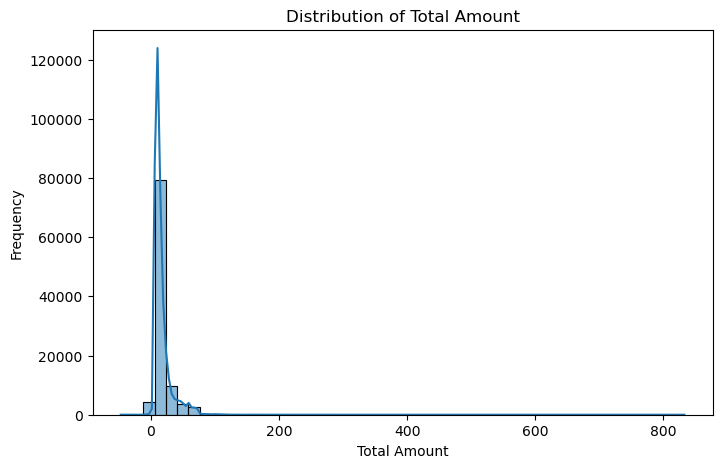

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(data['total_amount'], bins=50, kde=True)
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show() 

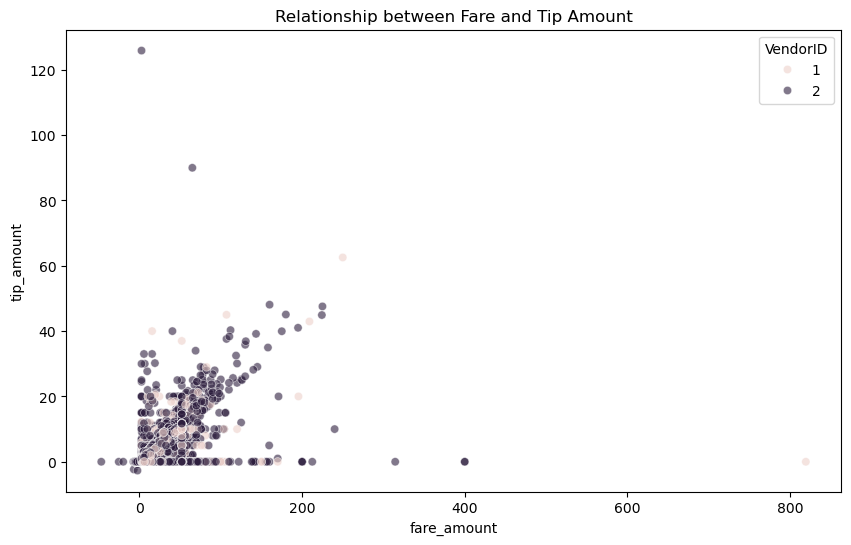

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fact_table, x='fare_amount', y='tip_amount', hue='VendorID', alpha=0.6)
plt.title('Relationship between Fare and Tip Amount')
plt.show()

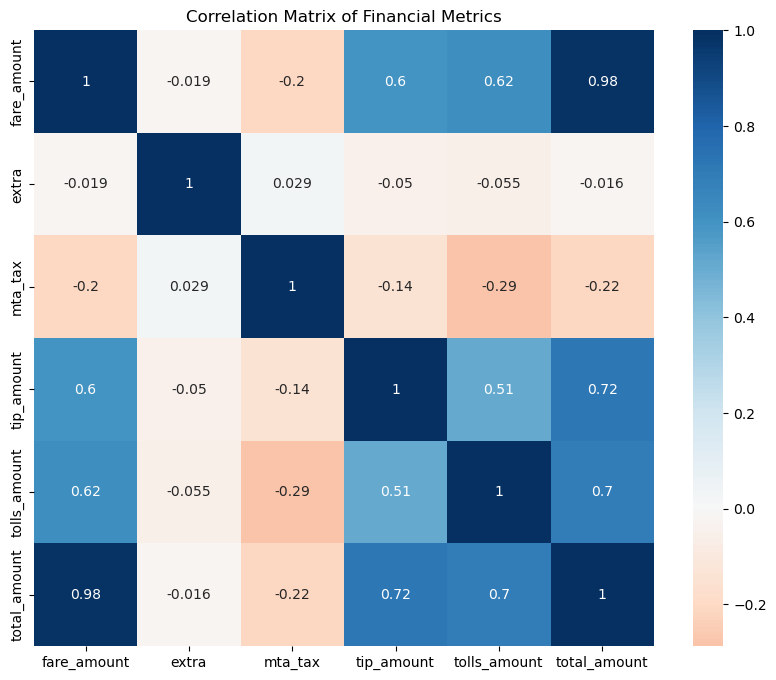

In [77]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Focus on financial columns
financial_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'total_amount']
sns.heatmap(fact_table[financial_cols].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Correlation Matrix of Financial Metrics')
plt.show()